## To train ANN on the processed data for churn

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
data = pd.read_csv('../Data/processed_customer_churn.csv')

In [3]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Credit card (automatic),Electronic check,Mailed check
0,0,0,1,0,1.0,0,0,1,0,1,...,0,0,0,1,29.85,3.396185,0,False,True,False
1,1,0,0,0,34.0,1,0,1,1,0,...,0,0,1,0,56.95,7.544068,0,False,False,True
2,1,0,0,0,2.0,1,0,1,1,1,...,0,0,0,1,53.85,4.683519,1,False,False,True
3,1,0,0,0,45.0,0,0,1,1,0,...,0,0,1,0,42.30,7.517928,0,False,False,False
4,0,0,0,0,2.0,1,0,2,0,0,...,0,0,0,1,70.70,5.021575,1,False,True,False


In [4]:
X = data.drop('Churn', axis= 1)
y = data['Churn']

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X = sc.fit_transform(X)

### traintest split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 0)

print(y_train.value_counts())
print(y_test.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


## Now we train the model

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Define the model
class ANNModel(nn.Module):
    def __init__(self):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(21, 50)
        self.fc2 = nn.Linear(50, 50)
        self.output = nn.Linear(50, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.output(x))
        return x


In [15]:
model = ANNModel()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create datasets for training and validation
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True)

# For validation, we'll use the test set (or you can create a separate validation split)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataloader = DataLoader(val_dataset, batch_size=100, shuffle=False)

# Lists to track losses
train_losses = []
val_losses = []

EPOCHS = 10
for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_dataloader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_dataloader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    # Calculate average losses
    avg_train_loss = train_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)
    
    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1/10, Train Loss: 0.5511, Val Loss: 0.4339
Epoch 2/10, Train Loss: 0.4319, Val Loss: 0.4057
Epoch 3/10, Train Loss: 0.4153, Val Loss: 0.4016
Epoch 4/10, Train Loss: 0.4100, Val Loss: 0.3996
Epoch 5/10, Train Loss: 0.4070, Val Loss: 0.4008
Epoch 6/10, Train Loss: 0.4042, Val Loss: 0.3995
Epoch 7/10, Train Loss: 0.4034, Val Loss: 0.3990
Epoch 8/10, Train Loss: 0.4012, Val Loss: 0.4000
Epoch 9/10, Train Loss: 0.3996, Val Loss: 0.4003
Epoch 10/10, Train Loss: 0.3992, Val Loss: 0.4001


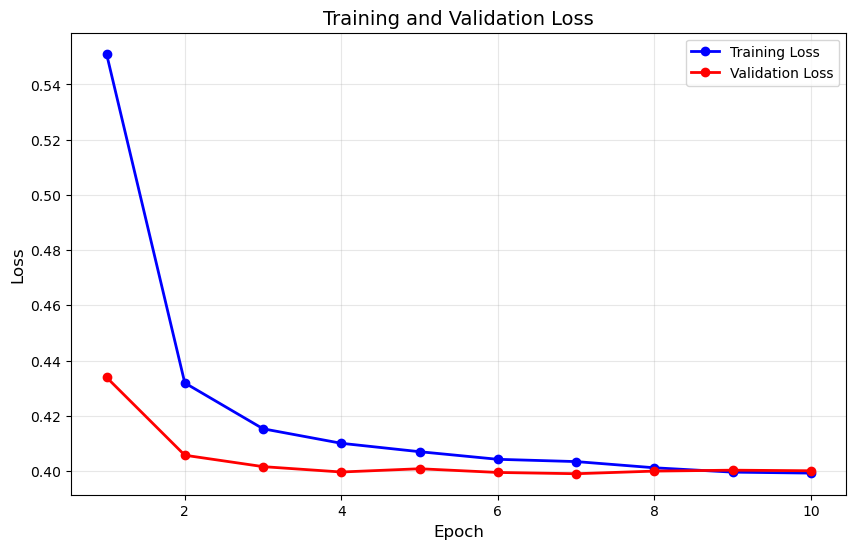

In [16]:
plt.figure(figsize=(10, 6))

epochs = range(1, EPOCHS + 1)

plt.plot(epochs, train_losses, 'b-o', label="Training Loss", linewidth=2)
plt.plot(epochs, val_losses, 'r-o', label="Validation Loss", linewidth=2)

plt.title("Training and Validation Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Model Evaluation on Test Data

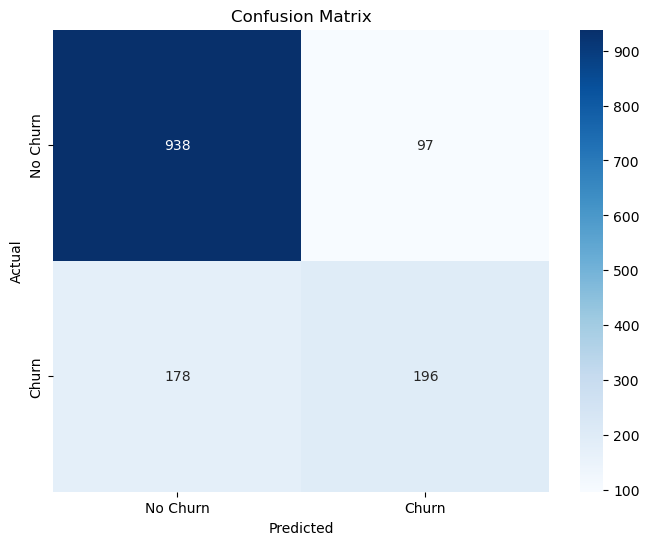

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_predictions = (test_outputs > 0.5).float()

y_test_np = y_test.values
y_pred_np = test_predictions.numpy().flatten()

cm = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test_np, y_pred_np, target_names=['No Churn', 'Churn']))

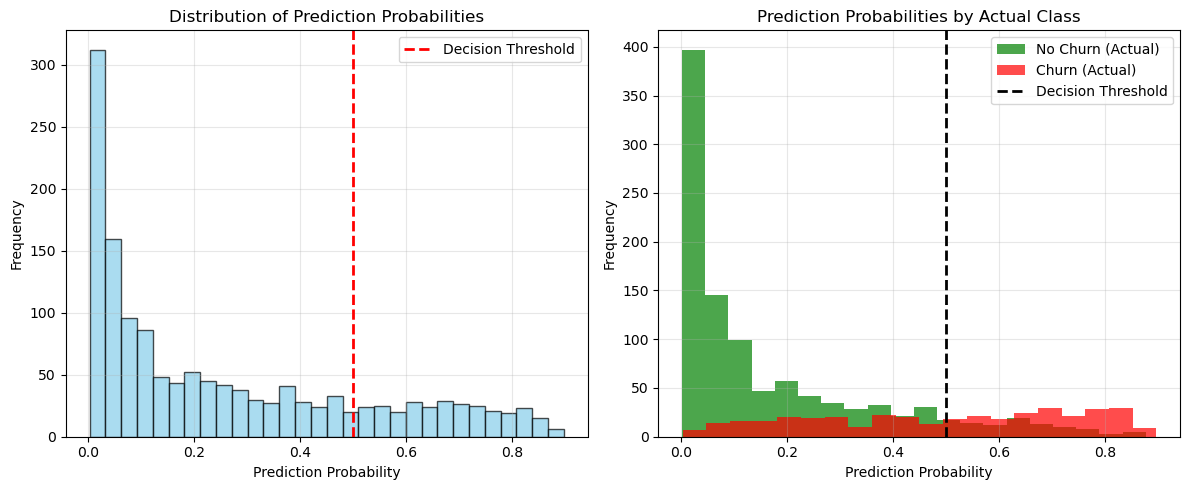

In [19]:
plt.figure(figsize=(12, 5))
# prediction probabilities histogram
plt.subplot(1, 2, 1)
plt.hist(test_outputs.numpy().flatten(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

# prediction probabilities by actual class
plt.subplot(1, 2, 2)
churn_probs = test_outputs.numpy().flatten()[y_test.values == 1]
no_churn_probs = test_outputs.numpy().flatten()[y_test.values == 0]

plt.hist(no_churn_probs, bins=20, alpha=0.7, label='No Churn (Actual)', color='green')
plt.hist(churn_probs, bins=20, alpha=0.7, label='Churn (Actual)', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.title('Prediction Probabilities by Actual Class')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Integrating SHAP

In [50]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Install shap if not already installed
# !pip install shap

# Define feature names
feature_names = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 
                'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 
                'TotalCharges', 'Credit card (automatic)', 'Electronic check', 'Mailed check']

print(f"Number of features: {len(feature_names)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Create a wrapper function for the model to work with SHAP
def model_predict_proba(X):
    """
    Wrapper function that returns prediction probabilities for SHAP
    """
    X_tensor = torch.tensor(X, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        # Return probabilities for both classes [prob_no_churn, prob_churn]
        prob_churn = outputs.numpy()
        prob_no_churn = 1 - prob_churn
        return np.column_stack([prob_no_churn, prob_churn])

# Create a background sample for SHAP (using a subset of training data)
background_sample = X_train[:100]  # Use 100 samples as background
print(f"Background sample shape: {background_sample.shape}")

# Initialize SHAP explainer
explainer = shap.KernelExplainer(model_predict_proba, background_sample)
print("SHAP explainer initialized successfully!")

Number of features: 21
X_train shape: (5634, 21)
X_test shape: (1409, 21)
Background sample shape: (100, 21)
SHAP explainer initialized successfully!


In [36]:
# Calculate SHAP values for a sample of test data
# Using a smaller sample for faster computation  
test_sample = X_test[:10]  # Use smaller sample first to debug
print(f"Calculating SHAP values for {test_sample.shape[0]} test samples...")
print(f"Test sample shape: {test_sample.shape}")

# This might take a few minutes depending on your system
shap_values = explainer.shap_values(test_sample)

print(f"Raw SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"SHAP values list length: {len(shap_values)}")
    for i, sv in enumerate(shap_values):
        print(f"SHAP values[{i}] shape: {sv.shape}")
    shap_values_churn = shap_values[1]  # Class 1 (churn) explanations
else:
    print(f"SHAP values shape: {shap_values.shape}")
    # For binary classification, SHAP might return values directly for positive class
    shap_values_churn = shap_values

print(f"Final SHAP values churn shape: {shap_values_churn.shape}")
print("SHAP calculation completed!")

# Expand to larger sample once we confirm it works
if test_sample.shape[0] == 10:
    print("\nExpanding to larger sample...")
    test_sample = X_test[:50]
    shap_values = explainer.shap_values(test_sample)
    if isinstance(shap_values, list):
        shap_values_churn = shap_values[1]
    else:
        shap_values_churn = shap_values
    print(f"Expanded SHAP values shape: {shap_values_churn.shape}")

# Remove the extra dimension if present
if len(shap_values_churn.shape) == 3:
    shap_values_churn = shap_values_churn.squeeze(-1)
    print(f"Final SHAP values shape after squeeze: {shap_values_churn.shape}")

Calculating SHAP values for 10 test samples...
Test sample shape: (10, 21)


  0%|          | 0/10 [00:00<?, ?it/s]

Raw SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (10, 21, 1)
Final SHAP values churn shape: (10, 21, 1)
SHAP calculation completed!

Expanding to larger sample...


  0%|          | 0/50 [00:00<?, ?it/s]

Expanded SHAP values shape: (50, 21, 1)
Final SHAP values shape after squeeze: (50, 21)


## SHAP Visualizations

Now let's create various SHAP visualizations to understand our model's decisions:

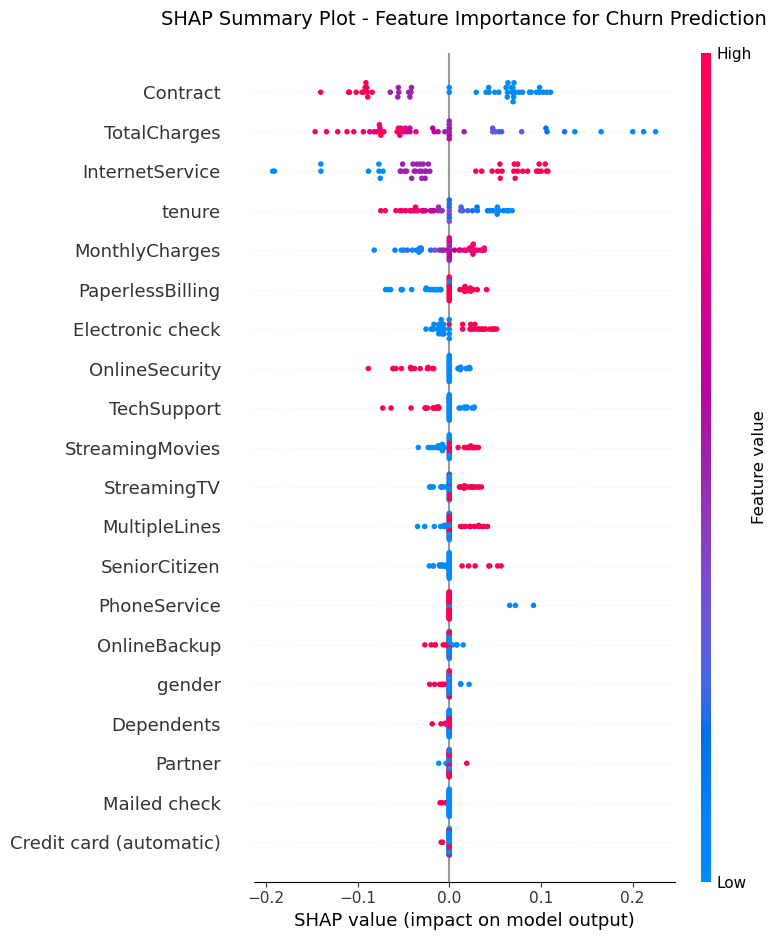

In [49]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_churn, test_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Importance for Churn Prediction', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

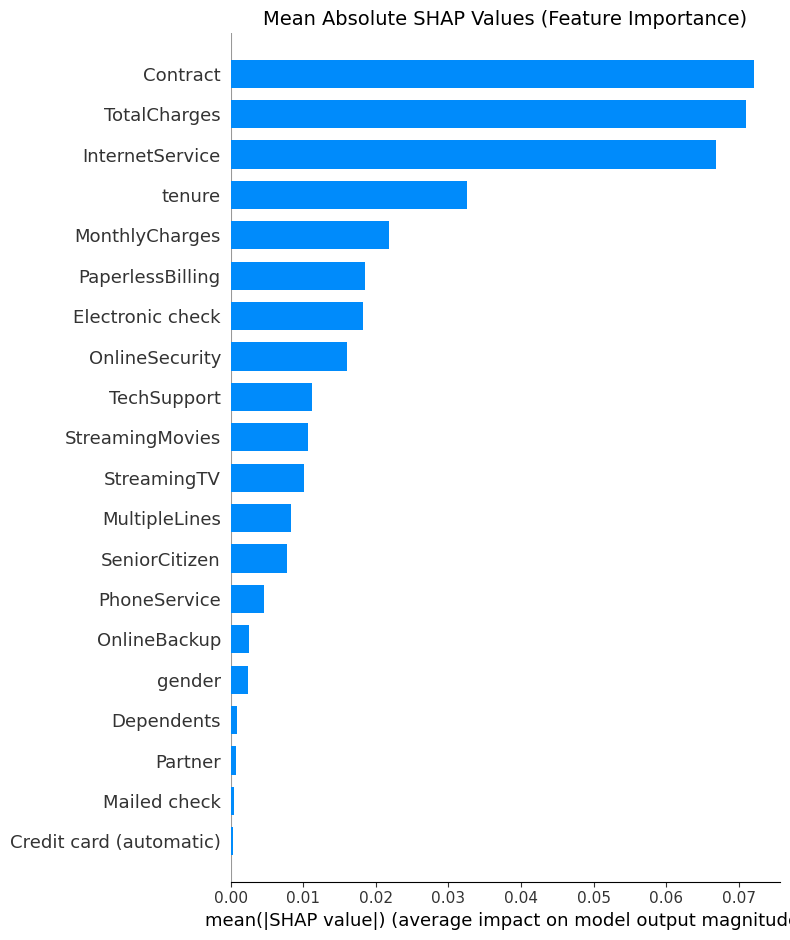


Top 10 Most Important Features:
 1. Contract                  0.0720
 2. TotalCharges              0.0710
 3. InternetService           0.0668
 4. tenure                    0.0326
 5. MonthlyCharges            0.0218
 6. PaperlessBilling          0.0185
 7. Electronic check          0.0182
 8. OnlineSecurity            0.0161
 9. TechSupport               0.0112
10. StreamingMovies           0.0107


In [38]:
# 2. Bar Plot - Shows mean absolute SHAP values (feature importance)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_churn, test_sample, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title('Mean Absolute SHAP Values (Feature Importance)', fontsize=14)
plt.tight_layout()
plt.show()

# Print feature importance ranking
mean_abs_shap = np.mean(np.abs(shap_values_churn), axis=0)
feature_importance = list(zip(feature_names, mean_abs_shap))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 Most Important Features:")
for i, (feature, importance) in enumerate(feature_importance[:10], 1):
    print(f"{i:2d}. {feature:<25} {importance:.4f}")


--- Sample 0 Analysis ---
Predicted churn probability: 0.011
Actual label: No Churn


<Figure size 1200x1000 with 0 Axes>

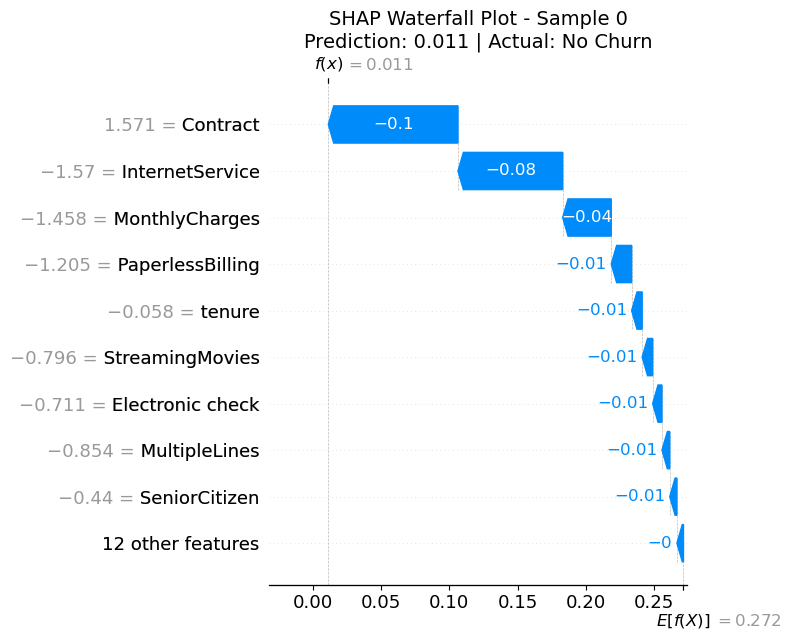


--- Sample 10 Analysis ---
Predicted churn probability: 0.797
Actual label: Churn


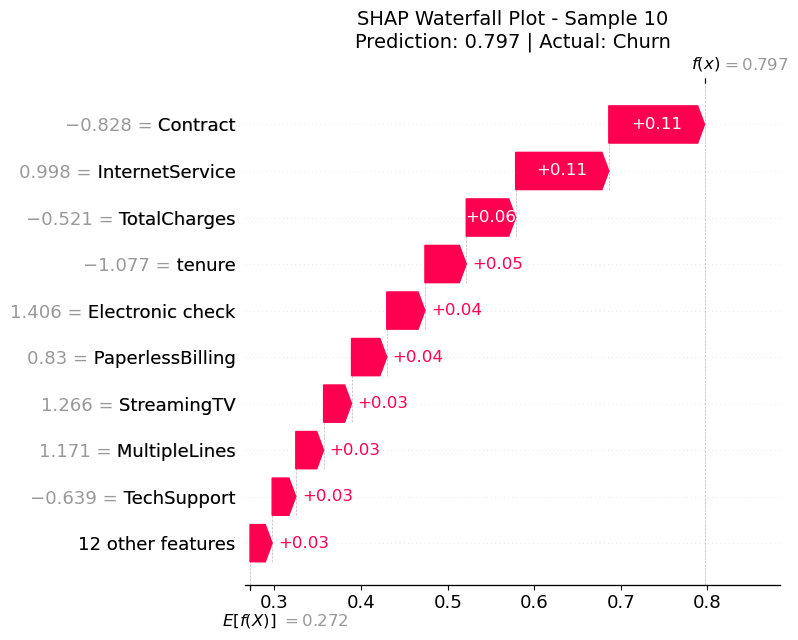


--- Sample 25 Analysis ---
Predicted churn probability: 0.071
Actual label: Churn


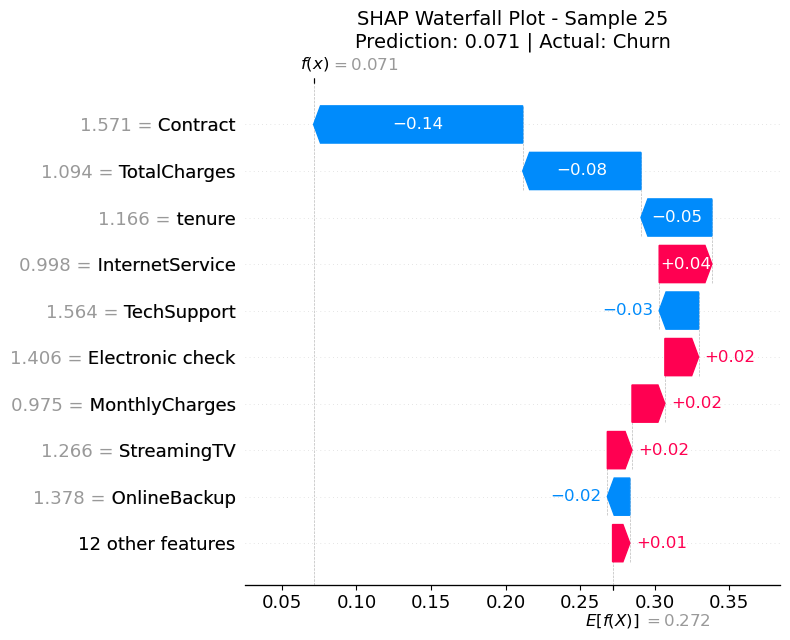

In [48]:
# 3. Waterfall Plot - Explain individual predictions
sample_indices = [0, 10, 25] 

for idx in sample_indices:
    # Get actual prediction for this sample
    sample_data = test_sample[idx:idx+1]
    X_tensor = torch.tensor(sample_data, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        prediction = outputs.numpy()[0, 0]  # Churn probability
    actual_label = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
    
    print(f"\n--- Sample {idx} Analysis ---")
    print(f"Predicted churn probability: {prediction:.3f}")
    print(f"Actual label: {'Churn' if actual_label == 1 else 'No Churn'}")
    
    # Create waterfall plot
    plt.figure(figsize=(12, 8))
    # Get base value - handle both single value and array cases
    if hasattr(explainer.expected_value, '__len__') and len(explainer.expected_value) > 1:
        base_value = explainer.expected_value[1]
    else:
        base_value = explainer.expected_value[0] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    
    # Create SHAP explanation object for waterfall plot
    explanation = shap.Explanation(values=shap_values_churn[idx], 
                                  base_values=base_value,
                                  data=test_sample[idx],
                                  feature_names=feature_names)
    
    shap.waterfall_plot(explanation, show=False)
    plt.title(f'SHAP Waterfall Plot - Sample {idx}\n' + 
              f'Prediction: {prediction:.3f} | Actual: {"Churn" if actual_label == 1 else "No Churn"}', 
              fontsize=14)
    plt.tight_layout()
    plt.show()